In [1]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from matplotlib.backends.backend_pgf import FigureCanvasPgf
matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)

matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'text.usetex': True,
    'font.family': 'serif',
    'pgf.rcfonts': False,
})

def read_files(files):
    data = []
    for f in files:
        data += [pd.read_csv(f, sep=',', skipinitialspace=True)]
    return data

dfs = read_files(['data/37.5.csv', 'data/75.csv', 'data/120.csv', 'data/157.5.csv'])


In [3]:
# Подгон всех графиков под одну начальную точку

times = [df['t (s)'] for df in dfs]
voltages = [df['V (mV)'] for df in dfs]

for i in range(1, voltages.__len__()):
    voltages[i] += (voltages[0].iloc[0] - voltages[i].iloc[0])


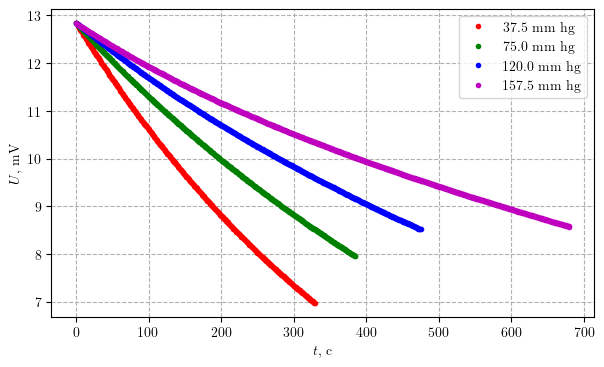

In [9]:
colors = ['red', 'green', 'blue', 'magenta']
labels = ['37.5 mm hg', '75.0 mm hg', '120.0 mm hg', '157.5 mm hg']

plt.figure(figsize=(7, 4))

for i in range(times.__len__()):
    plt.errorbar(times[i], voltages[i], fmt=f'{colors[i][0]}.', label=labels[i])

plt.xlabel('$t$, c')
plt.ylabel('$U$, mV')
plt.grid(linestyle='--')
plt.legend()
plt.savefig('pictures/raw.pdf')

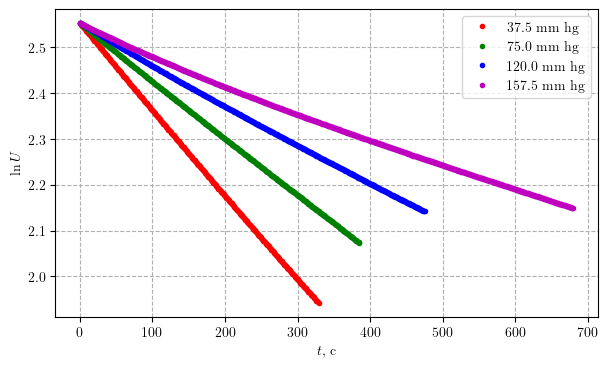

In [10]:
# Линеаризация

plt.figure(figsize=(7, 4))
log_volt = [np.log(v) for v in voltages]

for i in range(times.__len__()):
    plt.errorbar(times[i], log_volt[i], fmt=f'{colors[i][0]}.', label=labels[i])
    [a, b], cov = np.polyfit(times[i], log_volt[i], deg=1, cov=True)

plt.xlabel('$t$, c')
plt.ylabel('$\ln U$')
plt.grid(linestyle='--')
plt.legend()
plt.savefig('pictures/lin.pdf')